<h1><h1><center><Font size=30>Cleaning<Font><center><h1>

# My Libraries :

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from fuzzywuzzy import fuzz, process

# Remove Warnings :

In [2]:
import warnings
warnings.simplefilter("ignore")

# Figure Size :

In [3]:
from matplotlib import rcParams            
rcParams['figure.figsize'] = (16,6) 

# My Data :

In [4]:
data = pd.read_csv('Data.csv')
data

,ID,Gender,Age,Day,Duration,Country,Juice,Any comments ?
0,82235,Male,58.0,Tuesday,12 minutes,usa,Apple,Apple juice is good :)
1,82236,Male,58.0,Friday,24 minutes,Usa,Mango,thanks
2,82237,Male,34.0,Thursday,8 minutes,Usa,Apple,thanks
3,82238,Male,35.0,Tuesday,4 minutes,usa,Apple,I like orange juice
4,82239,Male,30.0,Wednesday,11 minutes,United states,Apple,No comments
...,...,...,...,...,...,...,...,...
96,82332,Male,36.0,Friday,14 minutes,Egypt,Apple,perfect
97,82332,Male,36.0,Friday,14 minutes,Egypt,Apple,perfect
98,82333,NaN,51.0,Saturday,18 minutes,Egypt,Apple,NaN
99,82330,Female,46.0,Wednesday,10 minutes,Egypt,Apple,NaN


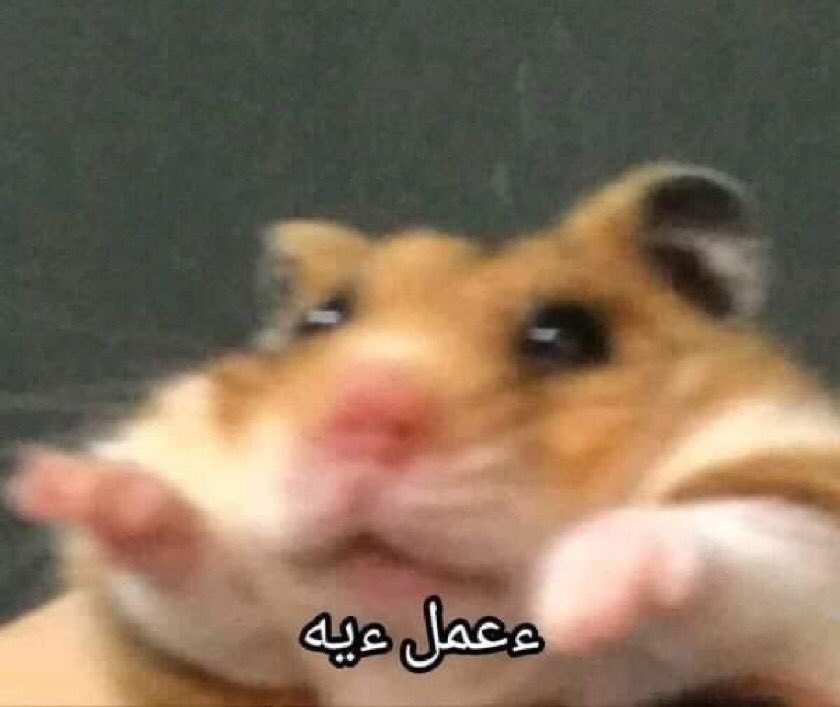

# Explore The Data :

In [5]:
print("Number of rows  is :",data.shape[0])
print("Number of columns  is :",data.shape[1])

Number of rows  is : 101
Number of columns  is : 8


### Check info :


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              101 non-null    int64  
 1   Gender          85 non-null     object 
 2   Age             93 non-null     float64
 3   Day             99 non-null     object 
 4   Duration        101 non-null    object 
 5   Country         101 non-null    object 
 6   Juice           94 non-null     object 
 7   Any comments ?  30 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 6.4+ KB


### Check Duplicates :

In [7]:
data.duplicated().sum()

2

In [8]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

0

### Show Summary Statistics of the Data :

In [9]:
data.describe()

,ID,Age
count,99.000000,9.100000e+01
mean,82284.090909,1.386157e+04
std,28.869195,1.317157e+05
min,82235.000000,2.700000e+01
25%,82259.500000,3.750000e+01
50%,82284.000000,4.600000e+01
75%,82308.500000,5.200000e+01
max,82335.000000,1.256541e+06


### Check NaN Values :

In [10]:
data.isna().sum()

ID                 0
Gender            16
Age                8
Day                2
Duration           0
Country            0
Juice              7
Any comments ?    71
dtype: int64

## We can show % of Nan Values :

In [11]:
(data.isna().sum() / len(data)) * 100

ID                 0.000000
Gender            16.161616
Age                8.080808
Day                2.020202
Duration           0.000000
Country            0.000000
Juice              7.070707
Any comments ?    71.717172
dtype: float64

# ----------------------------------------------------------------------------------------------------

# Data Cleaning :

# Make New Dataframe And Remove Useless Columns :

In [12]:
df = data.drop(['ID','Any comments ?'],axis=1)
df.head()

,Gender,Age,Day,Duration,Country,Juice
0,Male,58.0,Tuesday,12 minutes,usa,Apple
1,Male,58.0,Friday,24 minutes,Usa,Mango
2,Male,34.0,Thursday,8 minutes,Usa,Apple
3,Male,35.0,Tuesday,4 minutes,usa,Apple
4,Male,30.0,Wednesday,11 minutes,United states,Apple


# Clean `Gender` Column :

### Gender before cleaning :

In [13]:
print('Number of nan values is : ',df['Gender'].isna().sum(),'\n')
print(df['Gender'].value_counts())

Number of nan values is :  16 

Male      59
Female    24
Name: Gender, dtype: int64


### Visualizing Gender before cleaning

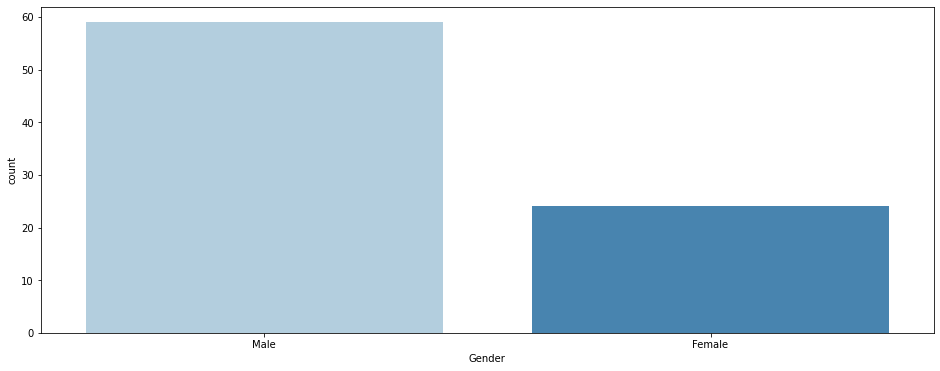

In [14]:
sns.countplot(x='Gender',data=df,palette='Blues')
plt.show()

### Now cleaning Gender :

In [15]:
df['Gender'].fillna("I don't want to say",inplace=True)

print('Number of nan values is : ',df['Gender'].isna().sum(),'\n')
print(df['Gender'].value_counts())

Number of nan values is :  0 

Male                   59
Female                 24
I don't want to say    16
Name: Gender, dtype: int64


### Visulaizing Gender After cleaning :

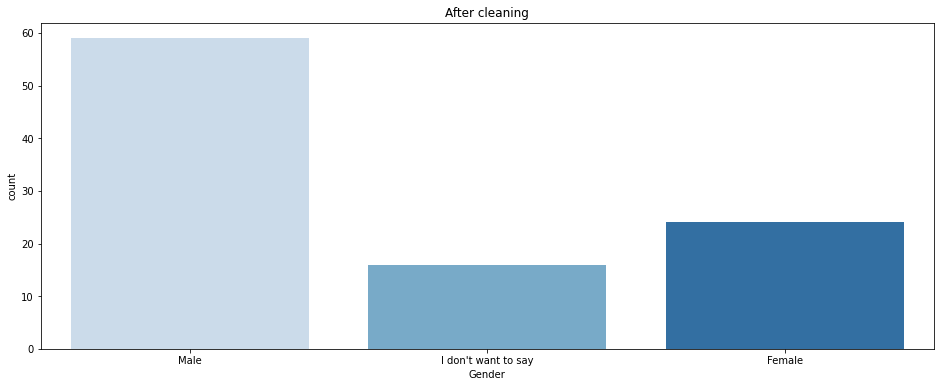

In [16]:
sns.countplot(x='Gender',data=df,palette='Blues')

plt.title('After cleaning')
plt.show()

# Clean `Age` Column :

In [17]:
df['Age'].describe()

count    9.100000e+01
mean     1.386157e+04
std      1.317157e+05
min      2.700000e+01
25%      3.750000e+01
50%      4.600000e+01
75%      5.200000e+01
max      1.256541e+06
Name: Age, dtype: float64

In [18]:
print('Number of nan values is : ',df['Age'].isna().sum(),'\n')

Number of nan values is :  8 



### Visualizing Age column before cleaning :

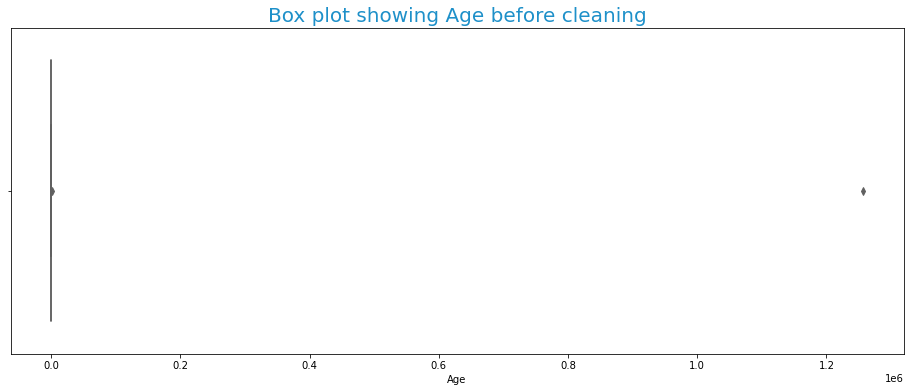

In [19]:
sns.boxplot(x='Age',data=df,palette='Blues')

plt.title('Box plot showing Age before cleaning',size=20,color='#1e90c9')
plt.show() 

### Cleaning Age Column :

In [20]:
df['Age'][df['Age'] > 85] = np.nan         
df['Age'][df['Age'] < 5] = np.nan

impute_by = int(np.round(df['Age'].mean()))
df['Age'].fillna(impute_by,inplace=True)
print('Number of nan values is : ',df['Age'].isna().sum(),'\n')

Number of nan values is :  0 



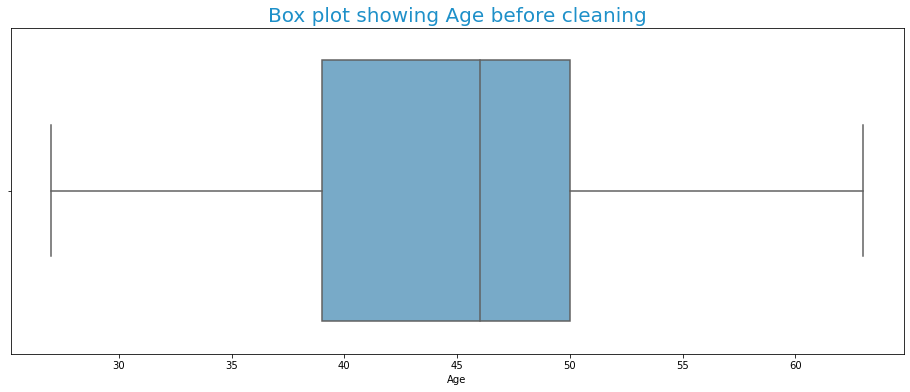

In [21]:
sns.boxplot(x='Age',data=df,palette='Blues')

plt.title('Box plot showing Age before cleaning',size=20,color='#1e90c9')
plt.show() 

# Clean `Day` Column :

In [22]:
print('Number of nan values is : ',df['Day'].isna().sum(),'\n')
print(df['Day'].value_counts())

Number of nan values is :  2 

Tuesday      23
Wednesday    20
Friday       16
Thursday     16
Sunday       12
Saturday      8
Monday        2
Name: Day, dtype: int64


### Impute using mode :

In [23]:
df['Day'].fillna(df['Day'].mode()[0],inplace=True)
print('Number of nan values is : ',df['Day'].isna().sum(),'\n')

Number of nan values is :  0 



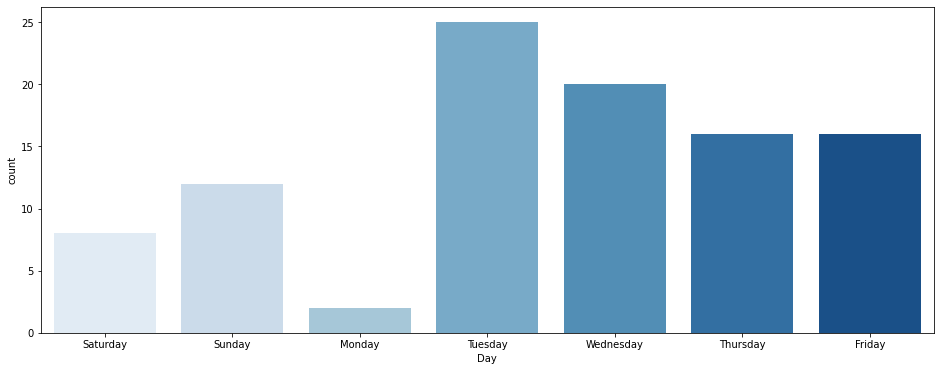

In [24]:
sns.countplot(x='Day',data=df,palette='Blues',order=['Saturday','Sunday','Monday','Tuesday','Wednesday','Thursday','Friday'])
plt.show()

# Clean `Duration` Column :

### Make duration as int value :

In [25]:
df['Duration'] = df['Duration'].str.strip('minutes')  # this will remove minutes
df['Duration'] = df['Duration'].astype('int')
df['Duration']

0      12
1      24
2       8
3       4
4      11
       ..
94      9
95     14
98     18
99     10
100     7
Name: Duration, Length: 99, dtype: int32

# Clean `Country` Column :

In [26]:
df['Country'].unique()

array(['usa', 'Usa', 'United states', 'Egypt', 'Egpt', 'china ',
       'England', 'Englannd', 'america', 'amrica', 'Usaa', 'spain',
       'spaina', 'Eggpt'], dtype=object)

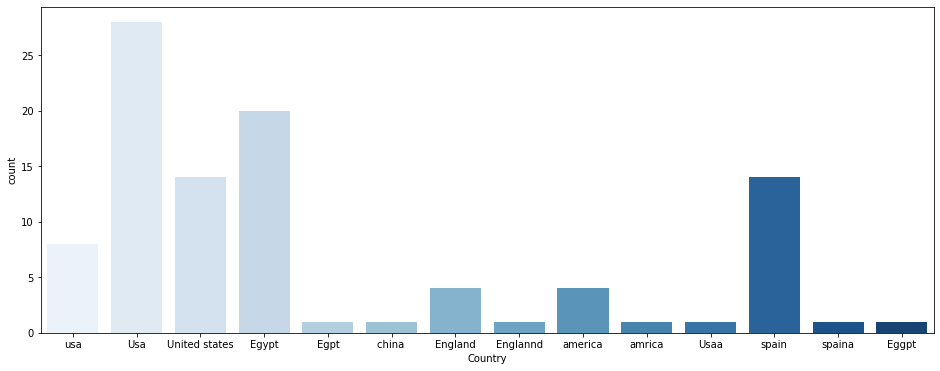

In [27]:
sns.countplot(x='Country',data=df,palette='Blues')

plt.show()

### Cleaning country column :

In [28]:
df['Country'] = df['Country'].str.strip().str.lower()

countries = pd.Series(['usa', 'united states','america','china','spain','Egypt','England'])

for country in countries:
    matches = process.extract(country, df['Country'], limit = df.shape[0])
    for potential_match in matches:
        if potential_match[1] >= 80:
            df.loc[df['Country'] == potential_match[0], 'Country'] = country
            
df['Country'].unique()

array(['usa', 'united states', 'Egypt', 'china', 'England', 'america',
       'spain'], dtype=object)

In [29]:
mapping = {'united states':'usa','america':'usa'}
df['Country'].replace(mapping,inplace=True)
df['Country'].unique()

array(['usa', 'Egypt', 'china', 'England', 'spain'], dtype=object)

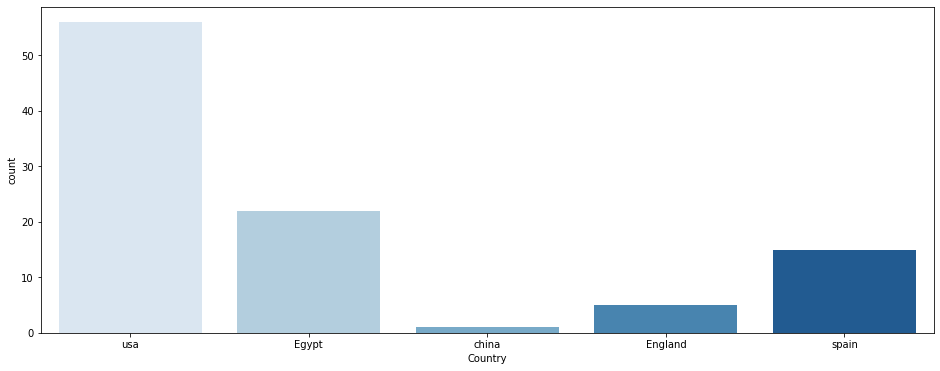

In [30]:
sns.countplot(x='Country',data=df,palette='Blues')

plt.show()

# Clean `Juice` Columns :

In [31]:
df['Juice'].head()

0    Apple
1    Mango
2    Apple
3    Apple
4    Apple
Name: Juice, dtype: object

### Showing number of nan values :

In [32]:
df['Juice'].isna().sum()

7

### Imputing NaN values in Juice columns :

In [33]:
df['Juice'].fillna("Didn't have a juice",inplace=True)
df['Juice'].isna().sum()

0

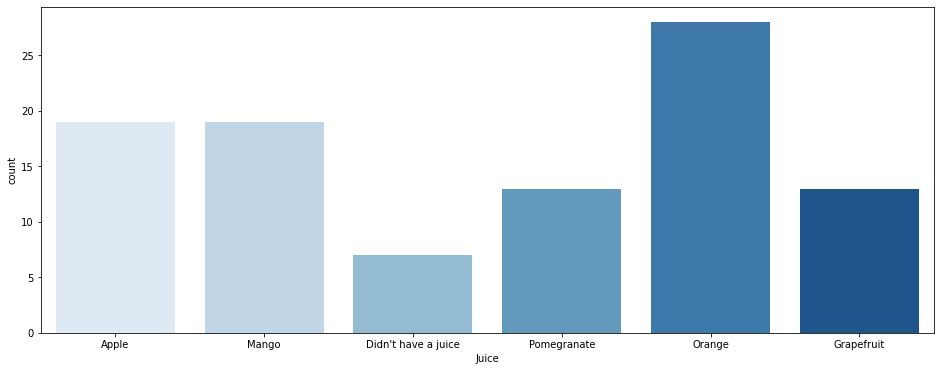

In [34]:
sns.countplot(x='Juice',data=df,palette='Blues')

plt.show()

# More Visualizations :)

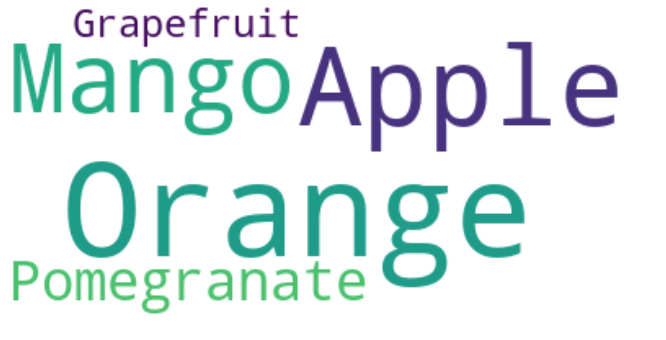

In [35]:
col = data['Juice'].dropna()
text = " ".join(cat for cat in col)


#wordcloud = WordCloud().generate(text)
word_cloud = WordCloud(collocations = False, background_color = 'white').generate(text)

plt.axis("off")
plt.imshow(word_cloud, interpolation='bilinear')
plt.show()

## Any Comments column :

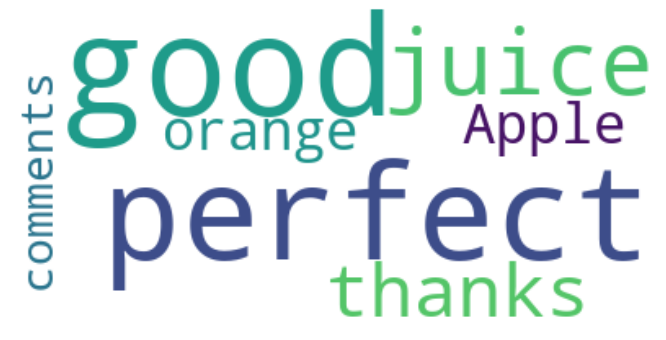

In [36]:
col = data['Any comments ?'].dropna()
text = " ".join(cat for cat in col)


#wordcloud = WordCloud().generate(text)
word_cloud = WordCloud(collocations = False, background_color = 'white').generate(text)

plt.axis("off")
plt.imshow(word_cloud, interpolation='bilinear')
plt.show()